In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Resume.csv")

In [3]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           2484 non-null   int64
 1   Resume_str   2484 non-null   str  
 2   Resume_html  2484 non-null   str  
 3   Category     2484 non-null   str  
dtypes: int64(1), str(3)
memory usage: 77.8 KB


In [5]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='str')

In [6]:
df.shape

(2484, 4)

In [7]:
df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

In [8]:
df["Category"].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

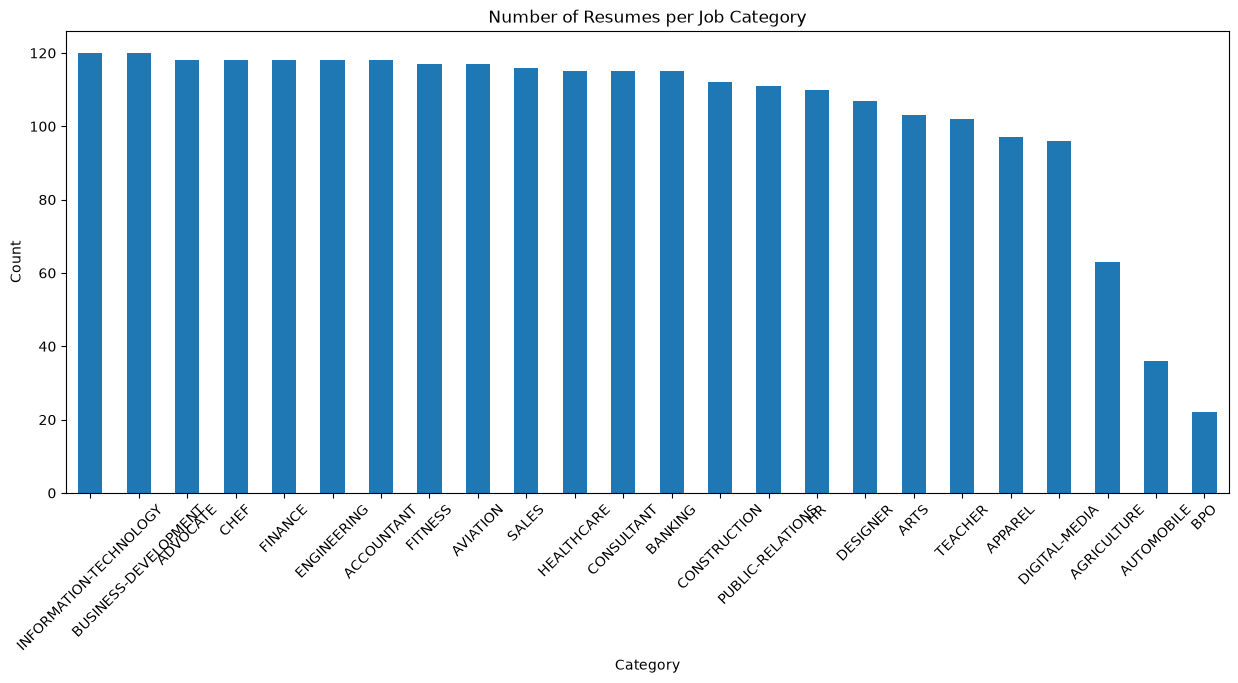

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
df["Category"].value_counts().plot(kind="bar")

plt.title("Number of Resumes per Job Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

In [10]:
print(df["Resume_str"][0])

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss preve

In [16]:
resume_df = df.copy()

In [17]:
import re

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [18]:
stop_words = ENGLISH_STOP_WORDS

def clean_resume(text):

    text = str(text).lower()

    text = re.sub(r'http\S+', ' ', text)

    text = re.sub(r'www\S+', ' ', text)

    text = re.sub(r'<.*?>', ' ', text)

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [19]:
resume_df["Cleaned_Resume"] = resume_df["Resume_str"].apply(clean_resume)

In [20]:
print("ORIGINAL\n")

print(resume_df["Resume_str"][0][:1000])

print("\n"+"="*80)

print("\nCLEANED\n")

print(resume_df["Cleaned_Resume"][0][:1000])

ORIGINAL

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, 

In [21]:
skills = [

# Programming Languages
"python","java","c","c++","c#","javascript","typescript","php","r","go","swift","kotlin","scala","ruby","matlab",

# Web Development
"html","css","bootstrap","react","angular","vue","node","express","django","flask","fastapi","jquery",

# Databases
"mysql","postgresql","sqlite","mongodb","oracle","sql","firebase","redis",

# Data Science
"numpy","pandas","matplotlib","seaborn","plotly","scikit-learn","tensorflow","keras","pytorch",
"xgboost","lightgbm","opencv","nlp","machine learning","deep learning","data analysis",

# Cloud
"aws","azure","gcp","docker","kubernetes","jenkins","git","github","linux",

# BI Tools
"power bi","tableau","excel",

# Soft Skills
"communication","leadership","teamwork","problem solving","project management","critical thinking",
"time management","customer service","presentation","analytical skills"
]

In [22]:
def extract_skills(text):

    text = text.lower()

    found_skills = []

    for skill in skills:

        if skill in text:

            found_skills.append(skill)

    return list(set(found_skills))

In [23]:
resume_df["Extracted_Skills"] = resume_df["Cleaned_Resume"].apply(extract_skills)

In [24]:
resume_df[["Category","Extracted_Skills"]].head()

,Category,Extracted_Skills
0,HR,"[customer service, go, c, aws, data analysis, ..."
1,HR,"[go, c, communication, git, r, presentation, p..."
2,HR,"[excel, go, c, customer service, r, leadership..."
3,HR,"[customer service, excel, c, communication, r,..."
4,HR,"[teamwork, excel, go, aws, c, problem solving,..."


In [25]:
print(resume_df["Extracted_Skills"][0])

['customer service', 'go', 'c', 'aws', 'data analysis', 'r', 'analytical skills', 'presentation', 'leadership', 'time management', 'swift']


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [27]:
job_description = """
We are looking for a Machine Learning Engineer.

Required Skills:
Python
Machine Learning
Deep Learning
SQL
TensorFlow
Scikit-learn
Pandas
NumPy
Git
Problem Solving
Communication
"""

In [28]:
documents = [job_description] + resume_df["Cleaned_Resume"].tolist()

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

In [29]:
similarity_scores = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
)

In [30]:
resume_df["Match Score"] = similarity_scores.flatten() * 100

In [31]:
top_candidates = resume_df.sort_values(
    by="Match Score",
    ascending=False
)

top_candidates[
    ["Category","Match Score","Extracted_Skills"]
].head(10)

,Category,Match Score,Extracted_Skills
926,AGRICULTURE,16.584063,"[tensorflow, c, go, javascript, node, scala, k..."
2291,ARTS,13.041010,"[r, leadership, c]"
1339,AUTOMOBILE,11.578985,"[mysql, pandas, numpy, excel, go, c, python, p..."
2153,BANKING,11.365157,"[go, c, python, r, sql, matlab, machine learning]"
194,DESIGNER,10.903683,"[project management, r, go, c]"
1762,ENGINEERING,10.254755,"[pandas, excel, go, c, python, data analysis, ..."
374,TEACHER,9.891771,"[excel, go, c, communication, problem solving,..."
349,TEACHER,9.292220,"[go, c, communication, problem solving, git, r..."
337,TEACHER,8.270066,"[excel, go, c, communication, r, leadership]"
1348,AUTOMOBILE,7.714299,"[sqlite, excel, c, go, python, data analysis, ..."


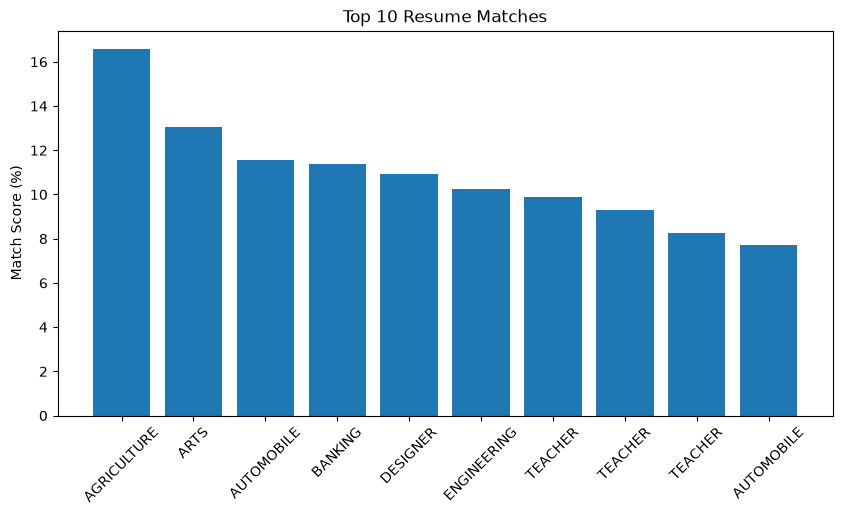

In [32]:
import matplotlib.pyplot as plt

top10 = top_candidates.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top10)),
    top10["Match Score"]
)

plt.xticks(
    range(len(top10)),
    top10["Category"],
    rotation=45
)

plt.ylabel("Match Score (%)")
plt.title("Top 10 Resume Matches")

plt.show()

In [33]:
job_skills = [
    "python",
    "machine learning",
    "deep learning",
    "sql",
    "tensorflow",
    "scikit-learn",
    "pandas",
    "numpy",
    "git",
    "communication",
    "problem solving"
]

In [34]:
def missing_skills(candidate_skills):
    return list(set(job_skills) - set(candidate_skills))

In [35]:
resume_df["Missing Skills"] = resume_df["Extracted_Skills"].apply(missing_skills)

In [36]:
top_candidates = resume_df.sort_values(
    by="Match Score",
    ascending=False
)

top_candidates[
    [
        "Category",
        "Match Score",
        "Extracted_Skills",
        "Missing Skills"
    ]
].head(10)

,Category,Match Score,Extracted_Skills,Missing Skills
926,AGRICULTURE,16.584063,"[tensorflow, c, go, javascript, node, scala, k...","[numpy, scikit-learn, problem solving, git, de..."
2291,ARTS,13.041010,"[r, leadership, c]","[pandas, numpy, tensorflow, scikit-learn, prob..."
1339,AUTOMOBILE,11.578985,"[mysql, pandas, numpy, excel, go, c, python, p...","[tensorflow, scikit-learn, communication, git,..."
2153,BANKING,11.365157,"[go, c, python, r, sql, matlab, machine learning]","[pandas, numpy, tensorflow, scikit-learn, prob..."
194,DESIGNER,10.903683,"[project management, r, go, c]","[pandas, numpy, tensorflow, scikit-learn, prob..."
1762,ENGINEERING,10.254755,"[pandas, excel, go, c, python, data analysis, ...","[numpy, tensorflow, scikit-learn, problem solv..."
374,TEACHER,9.891771,"[excel, go, c, communication, problem solving,...","[pandas, numpy, tensorflow, scikit-learn, pyth..."
349,TEACHER,9.292220,"[go, c, communication, problem solving, git, r...","[pandas, numpy, tensorflow, scikit-learn, pyth..."
337,TEACHER,8.270066,"[excel, go, c, communication, r, leadership]","[pandas, numpy, tensorflow, scikit-learn, prob..."
1348,AUTOMOBILE,7.714299,"[sqlite, excel, c, go, python, data analysis, ...","[pandas, numpy, tensorflow, scikit-learn, prob..."


In [37]:
candidate = top_candidates.iloc[0]

print("Top Candidate Category :", candidate["Category"])
print("\nMatch Score :", round(candidate["Match Score"],2),"%")

print("\nSkills Found:")
print(candidate["Extracted_Skills"])

print("\nMissing Skills:")
print(candidate["Missing Skills"])

Top Candidate Category : AGRICULTURE

Match Score : 16.58 %

Skills Found:
['tensorflow', 'c', 'go', 'javascript', 'node', 'scala', 'keras', 'mongodb', 'sql', 'flask', 'project management', 'java', 'html', 'leadership', 'pandas', 'excel', 'python', 'communication', 'r', 'react', 'tableau', 'css', 'matlab', 'express']

Missing Skills:
['numpy', 'scikit-learn', 'problem solving', 'git', 'deep learning', 'machine learning']


In [38]:
top_candidates.to_csv("Resume_Ranking_Results.csv", index=False)

print("Results exported successfully!")

Results exported successfully!


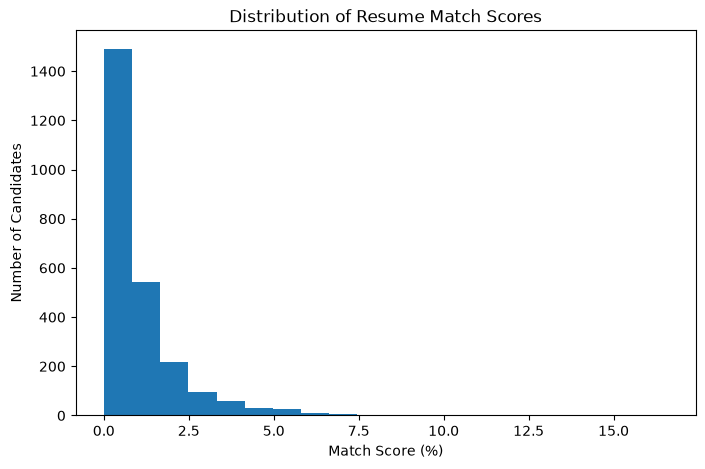

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(resume_df["Match Score"], bins=20)

plt.title("Distribution of Resume Match Scores")
plt.xlabel("Match Score (%)")
plt.ylabel("Number of Candidates")

plt.show()

In [40]:
print("="*50)
print("Resume Screening System Summary")
print("="*50)

print("Total Resumes:", len(resume_df))

print("Job Description: Machine Learning Engineer")

print("Highest Match:",
      round(top_candidates.iloc[0]["Match Score"],2),
      "%")

print("Lowest Match:",
      round(top_candidates.iloc[-1]["Match Score"],2),
      "%")

print("Average Match:",
      round(resume_df["Match Score"].mean(),2),
      "%")

Resume Screening System Summary
Total Resumes: 2484
Job Description: Machine Learning Engineer
Highest Match: 16.58 %
Lowest Match: 0.0 %
Average Match: 1.02 %


In [41]:
top_candidates[
    [
        "Category",
        "Match Score",
        "Extracted_Skills",
        "Missing Skills"
    ]
].head(10)

,Category,Match Score,Extracted_Skills,Missing Skills
926,AGRICULTURE,16.584063,"[tensorflow, c, go, javascript, node, scala, k...","[numpy, scikit-learn, problem solving, git, de..."
2291,ARTS,13.041010,"[r, leadership, c]","[pandas, numpy, tensorflow, scikit-learn, prob..."
1339,AUTOMOBILE,11.578985,"[mysql, pandas, numpy, excel, go, c, python, p...","[tensorflow, scikit-learn, communication, git,..."
2153,BANKING,11.365157,"[go, c, python, r, sql, matlab, machine learning]","[pandas, numpy, tensorflow, scikit-learn, prob..."
194,DESIGNER,10.903683,"[project management, r, go, c]","[pandas, numpy, tensorflow, scikit-learn, prob..."
1762,ENGINEERING,10.254755,"[pandas, excel, go, c, python, data analysis, ...","[numpy, tensorflow, scikit-learn, problem solv..."
374,TEACHER,9.891771,"[excel, go, c, communication, problem solving,...","[pandas, numpy, tensorflow, scikit-learn, pyth..."
349,TEACHER,9.292220,"[go, c, communication, problem solving, git, r...","[pandas, numpy, tensorflow, scikit-learn, pyth..."
337,TEACHER,8.270066,"[excel, go, c, communication, r, leadership]","[pandas, numpy, tensorflow, scikit-learn, prob..."
1348,AUTOMOBILE,7.714299,"[sqlite, excel, c, go, python, data analysis, ...","[pandas, numpy, tensorflow, scikit-learn, prob..."


In [43]:
best = top_candidates.iloc[0]

print("Top Candidate")
print("-"*50)

print("Category:", best["Category"])

print("Match Score:", round(best["Match Score"],2), "%")

print("\nSkills Found:")
print(best["Extracted_Skills"])

print("\nMissing Skills:")
print(best["Missing Skills"])
print("-"*50)

Top Candidate
--------------------------------------------------
Category: AGRICULTURE
Match Score: 16.58 %

Skills Found:
['tensorflow', 'c', 'go', 'javascript', 'node', 'scala', 'keras', 'mongodb', 'sql', 'flask', 'project management', 'java', 'html', 'leadership', 'pandas', 'excel', 'python', 'communication', 'r', 'react', 'tableau', 'css', 'matlab', 'express']

Missing Skills:
['numpy', 'scikit-learn', 'problem solving', 'git', 'deep learning', 'machine learning']
--------------------------------------------------


# Conclusion

This Resume Screening System successfully demonstrates an AI-assisted recruitment workflow.

The system:
- Cleaned and preprocessed resume text.
- Extracted technical and professional skills.
- Compared resumes against a job description using TF-IDF and Cosine Similarity.
- Ranked candidates based on relevance.
- Identified missing skills for each candidate.

This approach can help recruiters reduce manual effort, improve candidate shortlisting, and support data-driven hiring decisions.